# **Import necessary packages**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda



# **Section 1: Dataset Preparation**
*In this section you have to:*

1. Load the MNIST dataset
2. Apply necessary preprocessing to the dataset if needed
3. Use a data loader for batching the dataset. (Initial batch size: 32)


In [ ]:
# Dataset Preparation
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# 1) Define transforms:
#    - ToTensor + Normalize for all sets
#    - + simple data augmentations on TRAIN (e.g. random rotation & horizontal flip)
train_transform = transforms.Compose([
    transforms.RandomRotation(10),         # small rotation augmentation
    transforms.RandomHorizontalFlip(),     # random horizontal flip
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean & std
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2) Download the full MNIST TRAIN set (60k images) and split 70/20/10 → 42k/12k/6k
full_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=train_transform,
    download=True
)
n_total = len(full_train)
n_train = int(0.7 * n_total)    # 42,000
n_val   = int(0.2 * n_total)    # 12,000
n_test  = n_total - n_train - n_val  # 6,000

train_dataset, val_dataset, test_dataset = random_split(
    full_train,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# 3) Wrap in DataLoaders (batch size = 32 initially)
batch_size = 32

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)

print(f"Train / Val / Test sizes: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]

Train / Val / Test sizes: 42000 / 12000 / 6000


torch.Size([32, 1, 28, 28])
torch.Size([32])


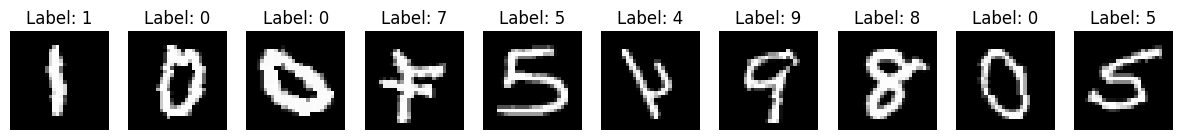

In [ ]:
images , labels = next(iter(test_loader))
print(images.shape)
print(labels.shape)

num_images = 10

# Create a figure
fig, axes = plt.subplots(1, num_images, figsize=(15, 2))

for i in range(num_images):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")
plt.show()

# **Section 2: Defining the Neural Network Model**

*In this section you have to:*

1.  Define an appropriate multi-layer perceptron (MLP) model.
2.  Define a suitable loss function and the SGD optimizer.
3.  Print the bias parameters of the last layer of the network.




In [ ]:
# Defining the Neural Network Model

import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        # 1) Flatten 28×28 → 784 so we can feed into Linear layers
        self.flatten = nn.Flatten()

        # 2) First hidden layer: 784 → 256
        #    - Linear
        #    - Batch Normalization
        #    - ReLU activation
        #    - Dropout for regularization
        self.fc1    = nn.Linear(28*28, 256)
        self.bn1    = nn.BatchNorm1d(256)
        self.relu1  = nn.ReLU()
        self.drop1  = nn.Dropout(p=0.2)

        # 3) Second hidden layer: 256 → 128
        #    - Linear
        #    - Batch Normalization
        #    - ReLU activation
        #    - Dropout
        self.fc2    = nn.Linear(256, 128)
        self.bn2    = nn.BatchNorm1d(128)
        self.relu2  = nn.ReLU()
        self.drop2  = nn.Dropout(p=0.2)

        # 4) Output layer: 128 → 10 classes (no activation here;
        #    CrossEntropyLoss will apply softmax internally)
        self.fc3    = nn.Linear(128, 10)

    def forward(self, x):
        # Flatten input
        x = self.flatten(x)

        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.drop1(x)

        # Layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.drop2(x)

        # Output layer
        x = self.fc3(x)
        return x


In [ ]:
# Initialize Model, Loss & Optimizer

import torch
import torch.nn as nn
import torch.optim as optim

# 1) Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2) Instantiate the model and move it to GPU/CPU
model     = MLP().to(device)

# 3) Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()            # for multi-class classification
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,                                 # initial learning rate
    momentum=0.9                             # add momentum for smoother updates
)

# 4) Print the initial bias parameters of the last (fc3) layer
print("Initial fc3.bias:", model.fc3.bias.data)


Using device: cuda
Initial fc3.bias: tensor([-0.0453,  0.0251, -0.0701,  0.0470,  0.0741,  0.0119,  0.0205,  0.0677,
         0.0808, -0.0044], device='cuda:0')


# **Section 3: Training and Testing function**

*In this section you have to:*

1. Compute accuracy and loss, use the utils function, you can use the torchmetrics library (if you want).
2. Implement the standard training and testing loop and train your model. (Also, compute the total training time using the time function.)


In [ ]:
# Training Function

from tqdm import tqdm

def train():
    """
    Trains the global `model` for one epoch on `train_loader`, using
    `criterion`, `optimizer`, and `device` from the global scope.
    Returns:
        epoch_loss (float): average loss over all training samples
        epoch_acc  (float): accuracy over all training samples
    """
    model.train()  # set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc='Training'):
        # 1) Move data to GPU/CPU
        images, labels = images.to(device), labels.to(device)

        # 2) Zero gradients
        optimizer.zero_grad()

        # 3) Forward pass
        outputs = model(images)

        # 4) Compute loss
        loss = criterion(outputs, labels)

        # 5) Backward pass + optimize
        loss.backward()
        optimizer.step()

        # 6) Accumulate metrics
        running_loss += loss.item() * labels.size(0)         # sum loss over batch
        _, preds = outputs.max(1)                            # predicted classes
        correct += preds.eq(labels).sum().item()             # count correct
        total += labels.size(0)                              # count samples

    # Compute averages
    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc




In [ ]:
# Evaluation Function

from tqdm import tqdm

def test(model, loader, device):
    """
    Evaluates `model` on `loader` (e.g., val_loader or test_loader).
    Returns:
        epoch_loss (float): average loss over all samples
        epoch_acc  (float): accuracy over all samples
    """
    model.eval()  # set model to eval mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no gradients during evaluation
        for images, labels in tqdm(loader, desc='Evaluating'):
            # 1) Move data to GPU/CPU
            images, labels = images.to(device), labels.to(device)

            # 2) Forward pass
            outputs = model(images)

            # 3) Compute loss
            loss = criterion(outputs, labels)

            # 4) Accumulate metrics
            running_loss += loss.item() * labels.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    # Compute averages
    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc


In [ ]:
# Training Loop

import time

# Number of epochs
epochs = 5

# Lists to store per‑epoch metrics
train_losses = []
test_accuracies = []

# Start timer
since = time.time()

for epoch in range(epochs):
    # 1) Train for one epoch
    train_loss, _ = train()

    # 2) Evaluate on the test set
    _, test_acc = test(model, test_loader, device)

    # 3) Record metrics
    train_losses.append(train_loss)
    test_accuracies.append(test_acc)

    # 4) Print progress
    print(f"Epoch {epoch+1}/{epochs} → "
          f"Train Loss: {train_loss:.4f}, "
          f"Test Accuracy: {test_acc*100:.2f}%")

# Compute elapsed time
time_elapsed = time.time() - since
print(f"\nTotal training time: {time_elapsed:.2f} seconds")


Evaluating: 100%|██████████| 188/188 [00:01<00:00, 104.34it/s]


Epoch 1/5 → Train Loss: 0.4881, Test Accuracy: 92.83%


Evaluating: 100%|██████████| 188/188 [00:01<00:00, 100.52it/s]


Epoch 2/5 → Train Loss: 0.3158, Test Accuracy: 93.72%


Evaluating: 100%|██████████| 188/188 [00:01<00:00, 102.43it/s]


Epoch 3/5 → Train Loss: 0.2690, Test Accuracy: 94.17%


Evaluating: 100%|██████████| 188/188 [00:02<00:00, 71.04it/s]


Epoch 4/5 → Train Loss: 0.2477, Test Accuracy: 94.63%


Evaluating: 100%|██████████| 188/188 [00:01<00:00, 99.94it/s] 

Epoch 5/5 → Train Loss: 0.2224, Test Accuracy: 95.13%

Total training time: 88.37 seconds


# **Section 4: Plot train loss and test accuracy**

*In this section you have to:*

1. Plot the learning curve (loss and accuracy vs. epochs).
2. Compute and print the total number of bias and weight parameters in your proposed model. (**Optional task**)


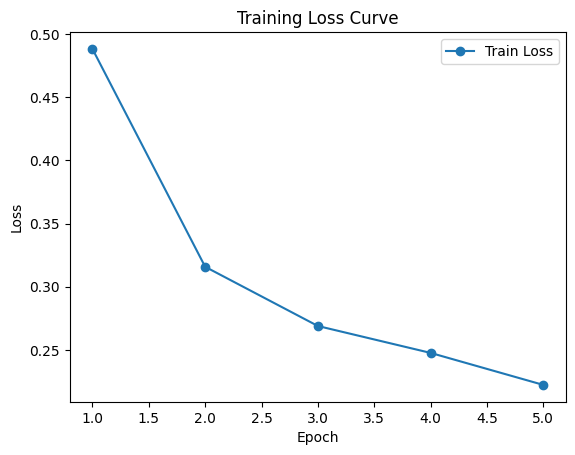

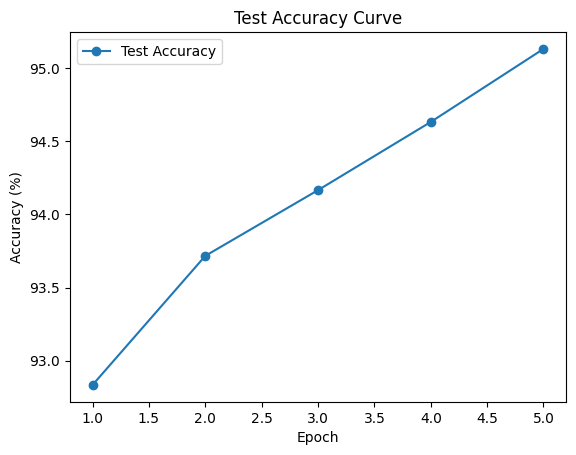

Total weight parameters: 235136
Total bias parameters:   778
Final fc3.bias: tensor([-0.0556,  0.0035, -0.0755,  0.0380, -0.0123,  0.0480, -0.0651,  0.0416,
         0.1807,  0.1042], device='cuda:0')


In [ ]:
# Plotting Learning Curves & Counting Parameters

import matplotlib.pyplot as plt

# 1) Plot Training Loss curve
plt.figure()
plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

# 2) Plot Test Accuracy curve
plt.figure()
# Convert to percentage for readability
plt.plot(range(1, epochs+1), [acc * 100 for acc in test_accuracies],
         marker='o', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()
plt.show()

# 3) Count total weight vs. bias parameters
total_weights = 0
total_biases  = 0
for name, param in model.named_parameters():
    if 'weight' in name:
        total_weights += param.numel()
    elif 'bias' in name:
        total_biases += param.numel()

print(f"Total weight parameters: {total_weights}")
print(f"Total bias parameters:   {total_biases}")

# 4) Print final fc3.bias for comparison
print("Final fc3.bias:", model.fc3.bias.data)


# **Section 5: Model Saving**

*In this section you have to:*

1. Save the trained model.
2. Load the saved model.
*TIP: You can use '`.state_dict`' for saving and loading the model*

In [ ]:
# Model Saving & Loading

import torch

def save_checkpoint(path='mlp_checkpoint.pth'):
    """
    Saves the model’s and optimizer’s state_dicts to the given filepath.
    """
    torch.save({
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, path)
    print(f"Checkpoint saved to {path}")

def load_checkpoint(path='mlp_checkpoint.pth'):
    """
    Loads model+optimizer states from the given filepath and
    moves the model back to the current device.
    """
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    model.to(device)
    print(f"Checkpoint loaded from {path}")


In [ ]:
# Model Evaluation on Test Data

from sklearn.metrics import classification_report

# 1) Save and reload the best checkpoint
save_checkpoint()
load_checkpoint()

# 2) Collect all predictions and true labels
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# 3) Print per‑class Precision, Recall, F1‑Score
print("Test Set Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4))


Checkpoint saved to mlp_checkpoint.pth
Checkpoint loaded from mlp_checkpoint.pth
Test Set Classification Report:

              precision    recall  f1-score   support

           0     0.9744    0.9811    0.9778       583
           1     0.9865    0.9865    0.9865       666
           2     0.9586    0.9252    0.9416       575
           3     0.9202    0.9453    0.9326       622
           4     0.9480    0.9782    0.9628       596
           5     0.9098    0.9151    0.9124       518
           6     0.9547    0.9672    0.9609       610
           7     0.9568    0.9802    0.9684       656
           8     0.9690    0.9414    0.9550       597
           9     0.9616    0.9116    0.9359       577

    accuracy                         0.9545      6000
   macro avg     0.9540    0.9532    0.9534      6000
weighted avg     0.9547    0.9545    0.9544      6000



# **Section 6: Hyperparameter Tuning**

1. Experiment with different values for the following hyperparameters:
  * Batch size: {4, 8, 16}
  * Learning rate: {0.1, 0.01, 0.001}
  * Number of layers: {2, 3, 4}(Plot the loss curve for different values of each hyperparameter.)
2. Train your model on CPU and compare the total training time with the training time on GPU
3. Besides ReLU, try two other activation functions discussed in the lesson: LeakyReLU and GELU.
**NOTE:** Only plot the accuracy vs. epochs curve in the designated cell for each experiment.



>>> Experiment: batch size = 4
  Epoch 1/5 → Val Loss: 0.5062, Test Acc: 85.85%
  Epoch 2/5 → Val Loss: 0.4417, Test Acc: 87.62%
  Epoch 3/5 → Val Loss: 0.4598, Test Acc: 86.33%
  Epoch 4/5 → Val Loss: 0.4004, Test Acc: 89.37%
  Epoch 5/5 → Val Loss: 0.3597, Test Acc: 90.03%

>>> Experiment: batch size = 8
  Epoch 1/5 → Val Loss: 0.3046, Test Acc: 91.00%
  Epoch 2/5 → Val Loss: 0.2486, Test Acc: 92.22%
  Epoch 3/5 → Val Loss: 0.2159, Test Acc: 93.33%
  Epoch 4/5 → Val Loss: 0.1980, Test Acc: 93.93%
  Epoch 5/5 → Val Loss: 0.1983, Test Acc: 93.65%

>>> Experiment: batch size = 16
  Epoch 1/5 → Val Loss: 0.2547, Test Acc: 92.30%
  Epoch 2/5 → Val Loss: 0.1996, Test Acc: 93.57%
  Epoch 3/5 → Val Loss: 0.1743, Test Acc: 94.60%
  Epoch 4/5 → Val Loss: 0.1584, Test Acc: 94.93%
  Epoch 5/5 → Val Loss: 0.1501, Test Acc: 95.43%


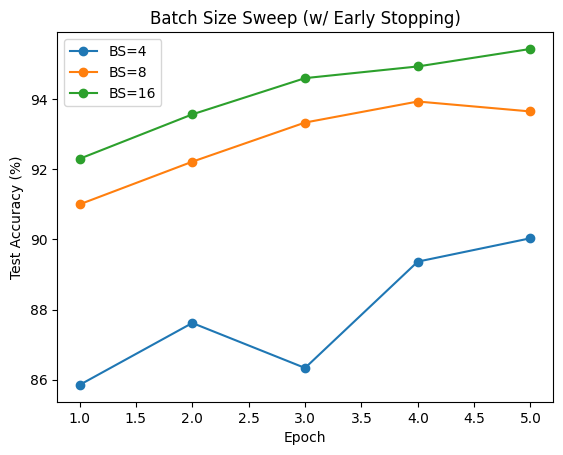

In [14]:
# Hyperparameter Tuning – Batch Size (w/ Early Stopping)

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import copy

patience = 2  # stop after 2 epochs with no val_loss improvement
batch_sizes = [4, 8, 16]
histories_bs = {}

for bs in batch_sizes:
    print(f"\n>>> Experiment: batch size = {bs}")
    tl = DataLoader(train_dataset, batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True)
    vl = DataLoader(val_dataset,   batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
    te = DataLoader(test_dataset,  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

    model_bs     = MLP().to(device)
    optimizer_bs = optim.SGD(model_bs.parameters(), lr=0.01, momentum=0.9)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    acc_list = []

    for epoch in range(1, epochs+1):
        train_one_epoch(model_bs, tl, criterion, optimizer_bs, device)
        val_loss, _ = evaluate(model_bs, vl, criterion, device)
        _, test_acc = evaluate(model_bs, te, criterion, device)

        print(f"  Epoch {epoch}/{epochs} → Val Loss: {val_loss:.4f}, Test Acc: {test_acc*100:.2f}%")
        acc_list.append(test_acc * 100)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model_bs.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model_bs.load_state_dict(best_state)
    histories_bs[bs] = acc_list

plt.figure()
for bs, accs in histories_bs.items():
    plt.plot(range(1, len(accs)+1), accs, marker='o', label=f"BS={bs}")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Batch Size Sweep (w/ Early Stopping)")
plt.legend()
plt.show()



>>> Experiment: learning rate = 0.1
  Epoch 1/5 → Val Loss: 0.2391, Test Acc: 92.25%
  Epoch 2/5 → Val Loss: 0.1907, Test Acc: 93.50%
  Epoch 3/5 → Val Loss: 0.1796, Test Acc: 94.18%
  Epoch 4/5 → Val Loss: 0.1738, Test Acc: 94.62%
  Epoch 5/5 → Val Loss: 0.1632, Test Acc: 94.60%

>>> Experiment: learning rate = 0.01
  Epoch 1/5 → Val Loss: 0.2366, Test Acc: 92.50%
  Epoch 2/5 → Val Loss: 0.1878, Test Acc: 94.00%
  Epoch 3/5 → Val Loss: 0.1633, Test Acc: 94.75%
  Epoch 4/5 → Val Loss: 0.1578, Test Acc: 94.93%
  Epoch 5/5 → Val Loss: 0.1377, Test Acc: 95.80%

>>> Experiment: learning rate = 0.001
  Epoch 1/5 → Val Loss: 0.3854, Test Acc: 88.28%
  Epoch 2/5 → Val Loss: 0.2654, Test Acc: 91.45%
  Epoch 3/5 → Val Loss: 0.2260, Test Acc: 92.88%
  Epoch 4/5 → Val Loss: 0.2021, Test Acc: 93.68%
  Epoch 5/5 → Val Loss: 0.1792, Test Acc: 94.32%


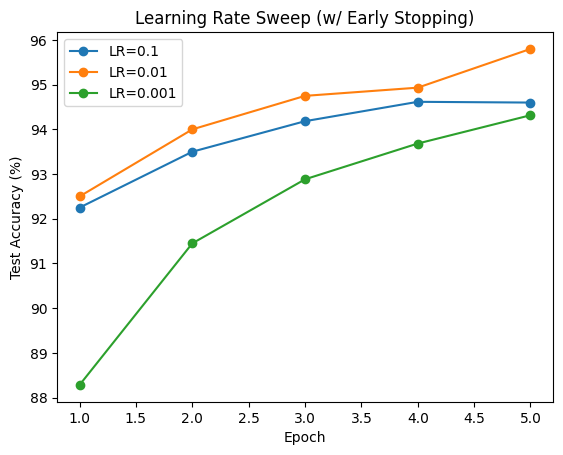

In [15]:
# Hyperparameter Tuning – Learning Rate (w/ Early Stopping)

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import copy

patience = 2
learning_rates = [0.1, 0.01, 0.001]
histories_lr = {}

# fixed batch size
tl = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vl = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
te = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

for lr in learning_rates:
    print(f"\n>>> Experiment: learning rate = {lr}")
    model_lr     = MLP().to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr, momentum=0.9)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    acc_list = []

    for epoch in range(1, epochs+1):
        train_one_epoch(model_lr, tl, criterion, optimizer_lr, device)
        val_loss, _ = evaluate(model_lr, vl, criterion, device)
        _, test_acc = evaluate(model_lr, te, criterion, device)

        print(f"  Epoch {epoch}/{epochs} → Val Loss: {val_loss:.4f}, Test Acc: {test_acc*100:.2f}%")
        acc_list.append(test_acc * 100)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model_lr.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model_lr.load_state_dict(best_state)
    histories_lr[lr] = acc_list

plt.figure()
for lr, accs in histories_lr.items():
    plt.plot(range(1, len(accs)+1), accs, marker='o', label=f"LR={lr}")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Learning Rate Sweep (w/ Early Stopping)")
plt.legend()
plt.show()



>>> Experiment: # hidden layers = 2
  Epoch 1/5 → Val Loss: 0.2349, Test Acc: 92.48%
  Epoch 2/5 → Val Loss: 0.1838, Test Acc: 94.00%
  Epoch 3/5 → Val Loss: 0.1570, Test Acc: 94.97%
  Epoch 4/5 → Val Loss: 0.1432, Test Acc: 95.28%
  Epoch 5/5 → Val Loss: 0.1403, Test Acc: 95.68%

>>> Experiment: # hidden layers = 3
  Epoch 1/5 → Val Loss: 0.2381, Test Acc: 92.03%
  Epoch 2/5 → Val Loss: 0.1853, Test Acc: 93.77%
  Epoch 3/5 → Val Loss: 0.1540, Test Acc: 94.98%
  Epoch 4/5 → Val Loss: 0.1421, Test Acc: 95.43%
  Epoch 5/5 → Val Loss: 0.1259, Test Acc: 95.78%

>>> Experiment: # hidden layers = 4
  Epoch 1/5 → Val Loss: 0.2542, Test Acc: 92.15%
  Epoch 2/5 → Val Loss: 0.1958, Test Acc: 93.67%
  Epoch 3/5 → Val Loss: 0.1633, Test Acc: 94.88%
  Epoch 4/5 → Val Loss: 0.1488, Test Acc: 95.67%
  Epoch 5/5 → Val Loss: 0.1404, Test Acc: 95.43%


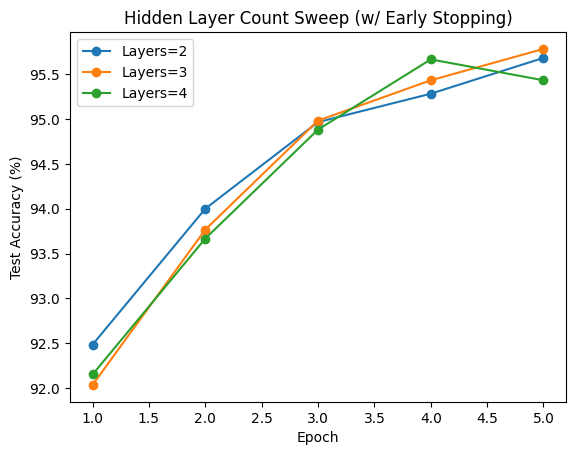

In [16]:
# Hyperparameter Tuning – # of Layers (w/ Early Stopping)

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import copy

# Helper to build MLP with variable hidden-layer count
def build_mlp_layers(num_hidden):
    layers = [nn.Flatten()]
    in_feats = 28*28
    for _ in range(num_hidden):
        layers += [
            nn.Linear(in_feats, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)
        ]
        in_feats = 256
    layers.append(nn.Linear(in_feats, 10))
    return nn.Sequential(*layers)

patience = 2
layer_counts = [2, 3, 4]
histories_nl = {}

tl = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vl = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
te = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

for nl in layer_counts:
    print(f"\n>>> Experiment: # hidden layers = {nl}")
    model_nl     = build_mlp_layers(nl).to(device)
    optimizer_nl = optim.SGD(model_nl.parameters(), lr=0.01, momentum=0.9)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    acc_list = []

    for epoch in range(1, epochs+1):
        # training
        model_nl.train()
        running_loss = correct = total = 0
        for images, labels in tl:
            images, labels = images.to(device), labels.to(device)
            optimizer_nl.zero_grad()
            outputs = model_nl(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_nl.step()
            running_loss += loss.item()*labels.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
        # validation & test
        val_loss, _  = evaluate(model_nl, vl, criterion, device)
        _, test_acc  = evaluate(model_nl, te, criterion, device)

        print(f"  Epoch {epoch}/{epochs} → Val Loss: {val_loss:.4f}, Test Acc: {test_acc*100:.2f}%")
        acc_list.append(test_acc * 100)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model_nl.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model_nl.load_state_dict(best_state)
    histories_nl[nl] = acc_list

plt.figure()
for nl, accs in histories_nl.items():
    plt.plot(range(1, len(accs)+1), accs, marker='o', label=f"Layers={nl}")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Hidden Layer Count Sweep (w/ Early Stopping)")
plt.legend()
plt.show()



>>> Experiment: Activation = ReLU
  Epoch 1/5 → Val Loss: 0.2351, Test Acc: 92.00%
  Epoch 2/5 → Val Loss: 0.1927, Test Acc: 93.53%
  Epoch 3/5 → Val Loss: 0.1593, Test Acc: 94.50%
  Epoch 4/5 → Val Loss: 0.1505, Test Acc: 95.22%
  Epoch 5/5 → Val Loss: 0.1368, Test Acc: 95.38%

>>> Experiment: Activation = LeakyReLU
  Epoch 1/5 → Val Loss: 0.2415, Test Acc: 92.35%
  Epoch 2/5 → Val Loss: 0.1942, Test Acc: 93.88%
  Epoch 3/5 → Val Loss: 0.1688, Test Acc: 94.38%
  Epoch 4/5 → Val Loss: 0.1455, Test Acc: 95.15%
  Epoch 5/5 → Val Loss: 0.1402, Test Acc: 95.43%

>>> Experiment: Activation = GELU
  Epoch 1/5 → Val Loss: 0.2319, Test Acc: 92.95%
  Epoch 2/5 → Val Loss: 0.1811, Test Acc: 94.47%
  Epoch 3/5 → Val Loss: 0.1617, Test Acc: 94.88%
  Epoch 4/5 → Val Loss: 0.1450, Test Acc: 95.07%
  Epoch 5/5 → Val Loss: 0.1324, Test Acc: 95.87%


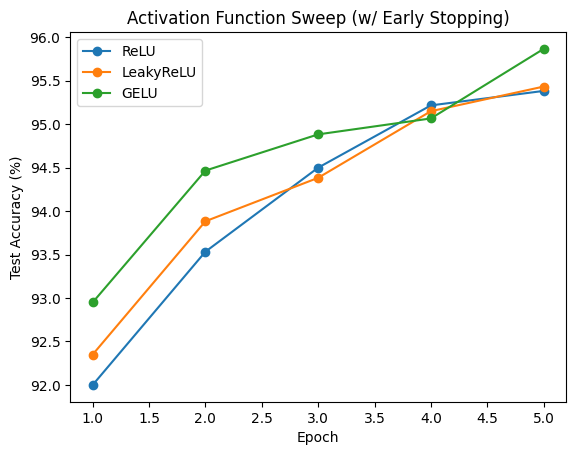

In [17]:
# Hyperparameter Tuning – Activation Functions (w/ Early Stopping)

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import copy

# Helper to build MLP with a given activation
def build_mlp_activation(activation):
    layers = [
        nn.Flatten(),
        nn.Linear(28*28, 256), nn.BatchNorm1d(256), activation, nn.Dropout(0.2),
        nn.Linear(256, 128),    nn.BatchNorm1d(128), activation, nn.Dropout(0.2),
        nn.Linear(128, 10)
    ]
    return nn.Sequential(*layers)

patience = 2
activations = {
    'ReLU':      nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(),
    'GELU':      nn.GELU()
}
histories_af = {}

tl = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vl = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
te = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

for name, act_fn in activations.items():
    print(f"\n>>> Experiment: Activation = {name}")
    model_af     = build_mlp_activation(act_fn).to(device)
    optimizer_af = optim.SGD(model_af.parameters(), lr=0.01, momentum=0.9)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    acc_list = []

    for epoch in range(1, epochs+1):
        train_one_epoch(model_af, tl, criterion, optimizer_af, device)
        val_loss, _ = evaluate(model_af, vl, criterion, device)
        _, test_acc = evaluate(model_af, te, criterion, device)

        print(f"  Epoch {epoch}/{epochs} → Val Loss: {val_loss:.4f}, Test Acc: {test_acc*100:.2f}%")
        acc_list.append(test_acc * 100)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model_af.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model_af.load_state_dict(best_state)
    histories_af[name] = acc_list

plt.figure()
for name, accs in histories_af.items():
    plt.plot(range(1, len(accs)+1), accs, marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Activation Function Sweep (w/ Early Stopping)")
plt.legend()
plt.show()



>>> Experiment: Optimizer = SGD
  Epoch 1/5 → Val Loss: 0.2311, Test Acc: 92.70%
  Epoch 2/5 → Val Loss: 0.1853, Test Acc: 94.03%
  Epoch 3/5 → Val Loss: 0.1652, Test Acc: 94.68%
  Epoch 4/5 → Val Loss: 0.1516, Test Acc: 95.02%
  Epoch 5/5 → Val Loss: 0.1391, Test Acc: 95.60%

>>> Experiment: Optimizer = RMSprop
  Epoch 1/5 → Val Loss: 0.3042, Test Acc: 90.57%
  Epoch 2/5 → Val Loss: 0.2097, Test Acc: 93.02%
  Epoch 3/5 → Val Loss: 0.1707, Test Acc: 94.62%
  Epoch 4/5 → Val Loss: 0.1725, Test Acc: 94.27%
  Epoch 5/5 → Val Loss: 0.1468, Test Acc: 95.58%

>>> Experiment: Optimizer = Adam
  Epoch 1/5 → Val Loss: 0.2283, Test Acc: 92.52%
  Epoch 2/5 → Val Loss: 0.2098, Test Acc: 93.18%
  Epoch 3/5 → Val Loss: 0.1741, Test Acc: 94.03%
  Epoch 4/5 → Val Loss: 0.1530, Test Acc: 94.80%
  Epoch 5/5 → Val Loss: 0.1471, Test Acc: 95.42%


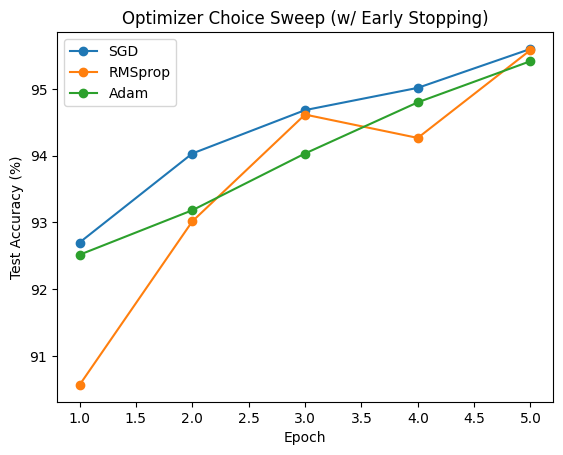

In [18]:
# Hyperparameter Tuning – Optimizer Choice (w/ Early Stopping)

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import copy

optimizers = {
    'SGD':    lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    'RMSprop':lambda params: optim.RMSprop(params, lr=0.01),
    'Adam':   lambda params: optim.Adam(params, lr=0.01)
}
histories_opt = {}
patience = 2

tl = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vl = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
te = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

for name, opt_fn in optimizers.items():
    print(f"\n>>> Experiment: Optimizer = {name}")
    model_opt     = MLP().to(device)
    optimizer_opt = opt_fn(model_opt.parameters())

    best_val_loss = float('inf')
    epochs_no_improve = 0
    acc_list = []

    for epoch in range(1, epochs+1):
        train_one_epoch(model_opt, tl, criterion, optimizer_opt, device)
        val_loss, _ = evaluate(model_opt, vl, criterion, device)
        _, test_acc = evaluate(model_opt, te, criterion, device)

        print(f"  Epoch {epoch}/{epochs} → Val Loss: {val_loss:.4f}, Test Acc: {test_acc*100:.2f}%")
        acc_list.append(test_acc * 100)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model_opt.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model_opt.load_state_dict(best_state)
    histories_opt[name] = acc_list

plt.figure()
for name, accs in histories_opt.items():
    plt.plot(range(1, len(accs)+1), accs, marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Optimizer Choice Sweep (w/ Early Stopping)")
plt.legend()
plt.show()


In [20]:
# Train the Best Model on GPU

import time
from sklearn.metrics import classification_report

# 1) Define best model architecture
def build_best_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
        nn.Linear(256, 256),   nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
        nn.Linear(256, 256),   nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
        nn.Linear(256, 10)
    )

# 2) Prepare data loaders with batch size = 16
bs = 16
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

# 3) Create model + optimizer
device = torch.device("cuda")
model = build_best_model().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# 4) Training loop with timing
epochs = 5
train_losses = []
test_accuracies = []
start_time = time.time()

for epoch in range(1, epochs+1):
    train_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer, device)
    _, test_acc = evaluate(model, test_loader, criterion, device)
    train_losses.append(train_loss)
    test_accuracies.append(test_acc * 100)
    print(f"Epoch {epoch} → Train Loss: {train_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

gpu_time = time.time() - start_time
print(f"\n Total training time on GPU: {gpu_time:.2f} seconds")

# 5) Evaluate on test set
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\n Classification Report (Best Model on GPU):\n")
print(classification_report(all_labels, all_preds, digits=4))


Epoch 1 → Train Loss: 0.5523, Test Acc: 92.15%
Epoch 2 → Train Loss: 0.3677, Test Acc: 94.13%
Epoch 3 → Train Loss: 0.3052, Test Acc: 94.65%
Epoch 4 → Train Loss: 0.2711, Test Acc: 95.35%
Epoch 5 → Train Loss: 0.2488, Test Acc: 95.82%

 Total training time on GPU: 122.41 seconds

 Classification Report (Best Model on GPU):

              precision    recall  f1-score   support

           0     0.9677    0.9760    0.9718       583
           1     0.9865    0.9895    0.9880       666
           2     0.9462    0.9478    0.9470       575
           3     0.9649    0.9277    0.9459       622
           4     0.9567    0.9648    0.9607       596
           5     0.9426    0.9189    0.9306       518
           6     0.9625    0.9672    0.9648       610
           7     0.9666    0.9710    0.9688       656
           8     0.9321    0.9665    0.9490       597
           9     0.9442    0.9376    0.9409       577

    accuracy                         0.9577      6000
   macro avg     0.9570 

In [21]:
# Train the Best Model on CPU

device = torch.device("cpu")
model_cpu = build_best_model().to(device)
optimizer_cpu = optim.SGD(model_cpu.parameters(), lr=0.01, momentum=0.9)

# Same loaders but no pin_memory
train_loader_cpu = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader_cpu  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# Train with timing
start_time = time.time()
for epoch in range(1, epochs+1):
    train_loss, _ = train_one_epoch(model_cpu, train_loader_cpu, criterion, optimizer_cpu, device)
    _, test_acc = evaluate(model_cpu, test_loader_cpu, criterion, device)
    print(f"Epoch {epoch} → Train Loss: {train_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

cpu_time = time.time() - start_time
print(f"\n Total training time on CPU: {cpu_time:.2f} seconds")


Epoch 1 → Train Loss: 0.5512, Test Acc: 92.18%
Epoch 2 → Train Loss: 0.3632, Test Acc: 93.98%
Epoch 3 → Train Loss: 0.2984, Test Acc: 94.73%
Epoch 4 → Train Loss: 0.2688, Test Acc: 95.15%
Epoch 5 → Train Loss: 0.2473, Test Acc: 95.95%

 Total training time on CPU: 118.22 seconds
